<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Computer-Vision/blob/main/Practicals/CR_Pract_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks/Computer Vision"

/content/drive/MyDrive/Colab Notebooks/Computer Vision


In [ ]:
img = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)
img_f = img.astype(np.float32)


In [ ]:
# 1. Mean / Averaging Filter (Linear)
mean_filt = cv2.blur(img, (5, 5))

# 2. Gaussian Filter (Linear)
gaussian_filt = cv2.GaussianBlur(img, (5, 5), 0)

# 3. Median Filter (Non-linear)
median_filt = cv2.medianBlur(img, 5)

# 4. Min Filter (Non-linear) - erosion with a square kernel
kernel = np.ones((5, 5), np.uint8)
min_filt = cv2.erode(img, kernel)

# 5. Max Filter (Non-linear) - dilation with a square kernel
max_filt = cv2.dilate(img, kernel)

# ---------------- First-order (gradient) sharpening filters ----------------

# 6. Sobel
sobel_x = cv2.Sobel(img_f, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_f, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobel_x, sobel_y)

# 7. Prewitt (OpenCV has no built-in, use filter2D)
prewitt_kx = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32)
prewitt_ky = np.array([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=np.float32)
prewitt_x = cv2.filter2D(img_f, -1, prewitt_kx)
prewitt_y = cv2.filter2D(img_f, -1, prewitt_ky)
prewitt_mag = cv2.magnitude(prewitt_x, prewitt_y)

# 8. Roberts Cross
roberts_kx = np.array([[1,0],[0,-1]], dtype=np.float32)
roberts_ky = np.array([[0,1],[-1,0]], dtype=np.float32)
roberts_x = cv2.filter2D(img_f, -1, roberts_kx)
roberts_y = cv2.filter2D(img_f, -1, roberts_ky)
roberts_mag = cv2.magnitude(roberts_x, roberts_y)



In [ ]:
# Sharpen using Sobel gradient magnitude
sharpened = img_f + sobel_mag
sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)


In [ ]:

# Normalize gradient images for display
sobel_disp = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
prewitt_disp = cv2.normalize(prewitt_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
roberts_disp = cv2.normalize(roberts_mag, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)



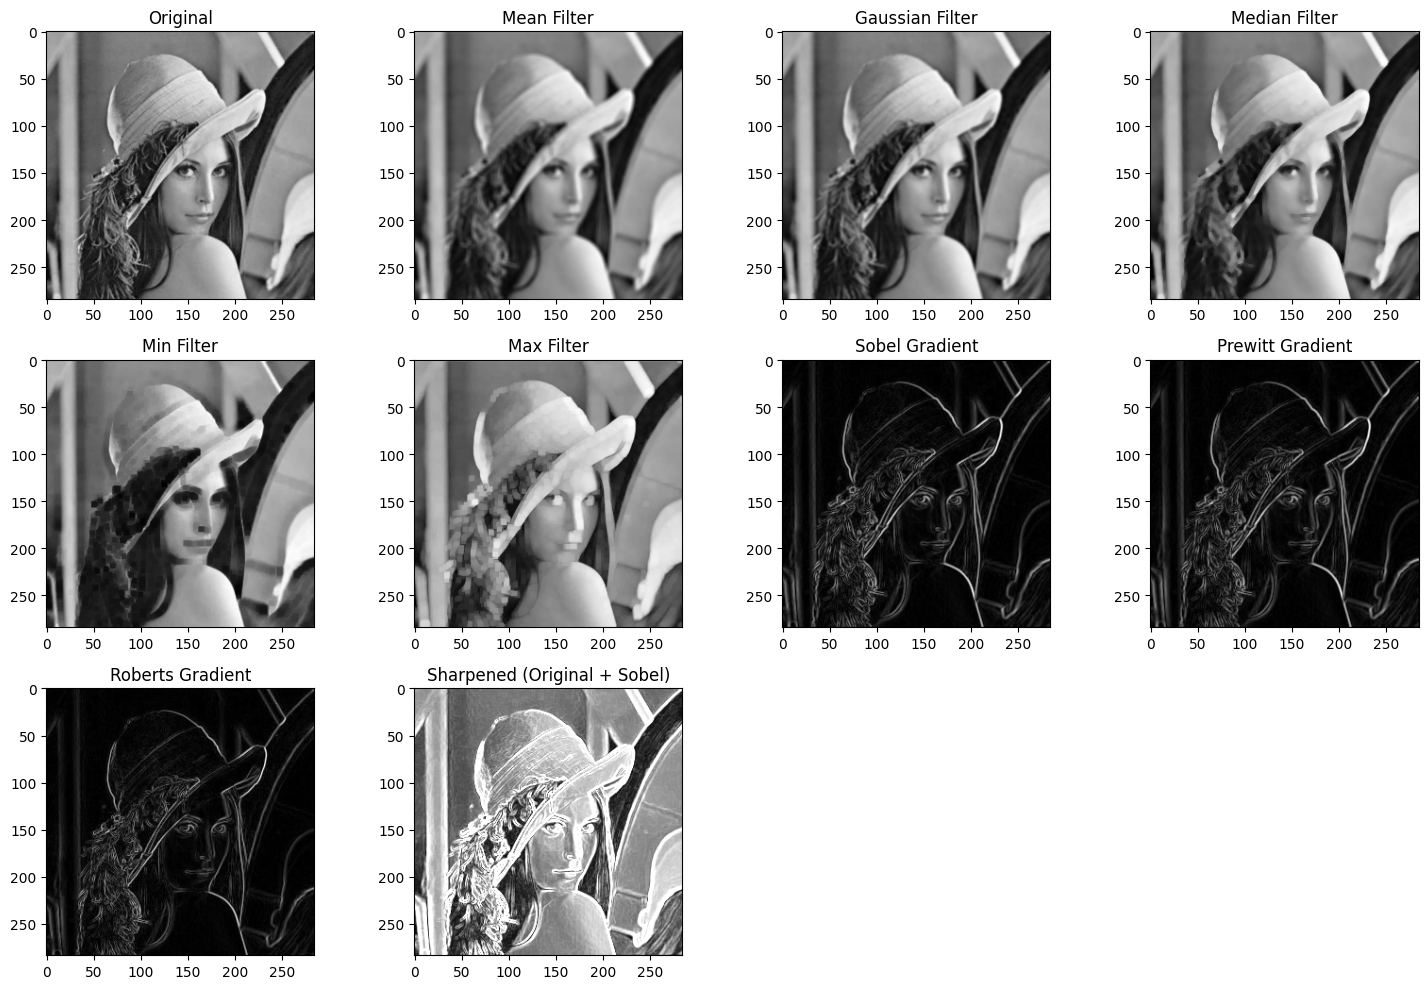

In [ ]:

# Display results
plt.figure(figsize=(15, 10))

plt.subplot(3, 4, 1),  plt.imshow(img, cmap='gray'),          plt.title('Original')
plt.subplot(3, 4, 2),  plt.imshow(mean_filt, cmap='gray'),    plt.title('Mean Filter')
plt.subplot(3, 4, 3),  plt.imshow(gaussian_filt, cmap='gray'),plt.title('Gaussian Filter')
plt.subplot(3, 4, 4),  plt.imshow(median_filt, cmap='gray'),  plt.title('Median Filter')
plt.subplot(3, 4, 5),  plt.imshow(min_filt, cmap='gray'),     plt.title('Min Filter')
plt.subplot(3, 4, 6),  plt.imshow(max_filt, cmap='gray'),     plt.title('Max Filter')
plt.subplot(3, 4, 7),  plt.imshow(sobel_disp, cmap='gray'),   plt.title('Sobel Gradient')
plt.subplot(3, 4, 8),  plt.imshow(prewitt_disp, cmap='gray'), plt.title('Prewitt Gradient')
plt.subplot(3, 4, 9),  plt.imshow(roberts_disp, cmap='gray'), plt.title('Roberts Gradient')
plt.subplot(3, 4, 10), plt.imshow(sharpened, cmap='gray'),    plt.title('Sharpened (Original + Sobel)')

plt.tight_layout()
plt.show()

